# Сравнение стандартов

## Сравнение стандартных отклонений в рамках нормальной модели

Пусть для выборок $\vec{x_n}$, $\vec{y_m}$ априорно задано нормальное распределение:
$$
\xi \sim N(\Theta, a^2), \newline
\eta \sim N(\Psi, b^2). \newline
$$
Для проверки гипотезы совпадения дисперсий
$$
H_0: ~ a^2 = b^2 \newline
H_1: ~ a^2 \ne b^2
$$
с уровнем значимости $\alpha = 0.05$ используем критерий
$$
\Delta = {S_x^2 \over a^2} \cdot {b^2 \over S_y^2} \sim F(n-1, m-1); \newline
G: \tilde{\Delta} \in [0, F_{\alpha \over 2}) \cup (F_{1 - {\alpha \over 2}}, +\inf), \newline
P(\Delta \in C | H_0) = \alpha
$$


## Вычисление критической областей и оценок

In [2]:
from scipy.stats import f  # Fisher distribution
from matplotlib import pyplot as plt
import numpy as np

In [3]:
# init
ALPHA = 0.05
N, M = 139, 1000
C_LEFT, C_RIGHT = f.ppf(ALPHA / 2, N-1, M-1), f.ppf(1 - ALPHA / 2, N-1, M-1)
s_len_x, s_len_y = 5.722, 6.161
s_wid_x, s_wid_y = 4.612, 5.055

In [4]:
delta_len = (s_len_x / s_len_y) ** 2
delta_wid = (s_wid_x / s_wid_y) ** 2

In [5]:
def check_hypotesis(delta):
    if (delta < C_LEFT) or (delta > C_RIGHT):
        return "Reject"
    return "Can't reject"

In [6]:
print(f"{check_hypotesis(delta_len)} lenght standart equality hypotesis")
print(f"{check_hypotesis(delta_wid)} widht standart equality hypotesis")

Can't reject lenght standart equality hypotesis
Can't reject widht standart equality hypotesis


## Построение $W(\theta)$

Где $\theta = \large{a^2 \over b^2}$

In [7]:
# implementing W function
def W(theta):
    return f.cdf(C_LEFT / theta, N-1, M-1) + f.sf(C_RIGHT / theta, N-1, M-1)

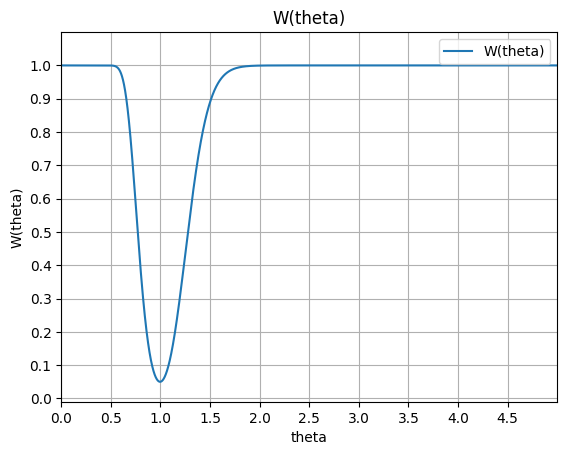

In [8]:
fig, axis = plt.subplots()
theta = np.linspace(1e-5, 5, 50000)

axis.plot(theta, W(theta), label="W(theta)")

axis.set_ylim(-0.01, 1.1)
axis.set_yticks(np.arange(0, 1.1, 0.1))
axis.set_ylabel("W(theta)")

axis.set_xlim(0.0, 5)
axis.set_xticks(np.arange(0, 5, 0.5))
axis.set_xlabel("theta")

axis.legend()
axis.set_title("W(theta)")

axis.grid(True)

plt.show()

In [9]:
W(delta_len)

np.float64(0.1944649751230961)

In [10]:
W(delta_wid)

np.float64(0.27649067533294386)